<a href="https://colab.research.google.com/github/radwaelreedy/DEPI_Tech_Journey/blob/main/AssigmentDEPI_Linear_Regression/AssigmentDEPI_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [ ]:
data = pd.read_csv('Salary_Data.csv')
data.shape

(30, 2)

In [ ]:
x = data.iloc[ : , :-1].values
y = data.iloc[ :, 1].values


In [ ]:
mean_salary = y.mean()  # Average salary in your dataset
min_salary = y.min()
max_salary = y.max()
print(mean_salary)
print(min_salary)
print(max_salary)
relative_error = 4834 / mean_salary * 100
print(relative_error)

76003.0
37731.0
122391.0
6.360275252292673


In [ ]:
#display the First 5 rows
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [ ]:
#display the last 5 rows
data.tail()

,YearsExperience,Salary
25,9.0,105582.0
26,9.5,116969.0
27,9.6,112635.0
28,10.3,122391.0
29,10.5,121872.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [ ]:
data.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [ ]:
data.shape

(30, 2)

<Axes: xlabel='YearsExperience', ylabel='Salary'>

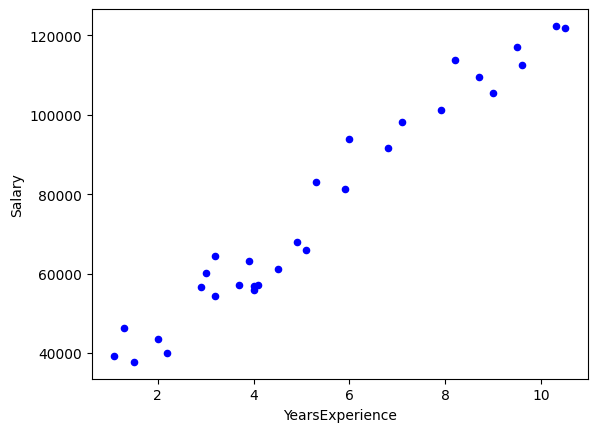

In [ ]:
# These Plots help to explain the values and how they are scattered
# Plot a scatter plot
data.plot(x ='YearsExperience', y = 'Salary', kind = 'scatter', color ='blue')

In [ ]:
# Cooking the data
X = data['YearsExperience']
X.head()

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2


In [ ]:
# Cooking the data
y = data['Salary']
y.head()

,Salary
0,39343.0
1,46205.0
2,37731.0
3,43525.0
4,39891.0


In [ ]:
# Split the data for train and test (70% for training)
xtrain, xtest , ytrain, ytest = train_test_split( x ,y, test_size = 0.3, random_state = 0)


In [ ]:
# Create new axis for x column
xtrain = xtrain[:,np.newaxis]
xtest = xtest[:,np.newaxis]

In [ ]:
print(xtrain.shape)
print(ytrain.shape)
print(xtest.shape)
print(ytest.shape)

(21, 1)
(21,)
(9, 1)
(9,)


In [ ]:
# Importing Linear Regression model from scikit learn
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

In [ ]:
# Fitting the model
regressor.fit(xtrain, ytrain)

LinearRegression()

In [ ]:
y_pred = regressor.predict(xtest)

In [ ]:
y_pred[:8]

array([ 40817.78327049, 123188.08258899,  65154.46261459,  63282.41035735,
       115699.87356004, 108211.66453108, 116635.89968866,  64218.43648597])

In [ ]:
ytest[:8]

,Salary
2,37731.0
28,122391.0
13,57081.0
10,63218.0
26,116969.0
24,109431.0
27,112635.0
11,55794.0


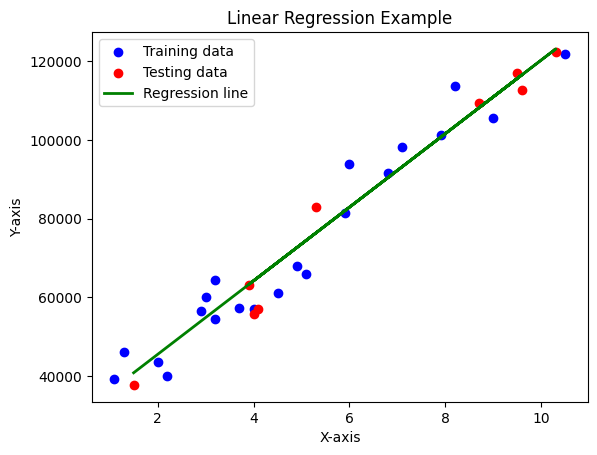

In [ ]:
#plot the traing data , testing data and the Regression line
plt.scatter(xtrain, ytrain, color ='blue', label ='Training data')
plt.scatter(xtest, ytest, color='red', label ='Testing data')
plt.plot(xtest, y_pred, color = 'green',linewidth=2, label ='Regression line')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.title('Linear Regression Example')
plt.show()


In [ ]:
ytest.shape

(9,)

In [ ]:
c = [i for i in range (1,len(ytest)+1,1)]
c

[1, 2, 3, 4, 5, 6, 7, 8, 9]

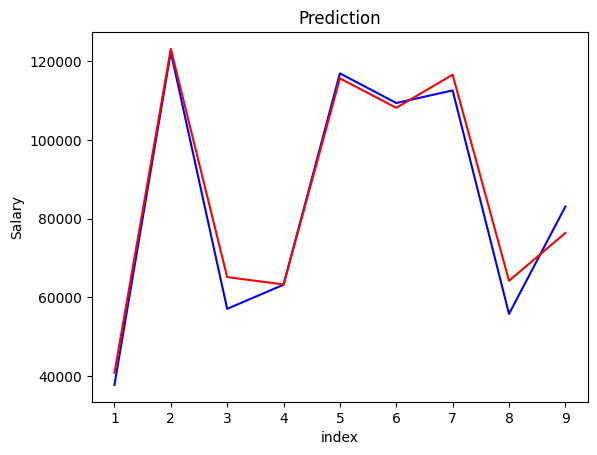

In [ ]:
c = [i for i in range (1,10,1)]
plt.plot(c,ytest,color='blue',linestyle='-')
plt.plot(c,y_pred,color='red',linestyle='-')
plt.ylabel('Salary')
plt.xlabel('index')
plt.title('Prediction')
plt.show()

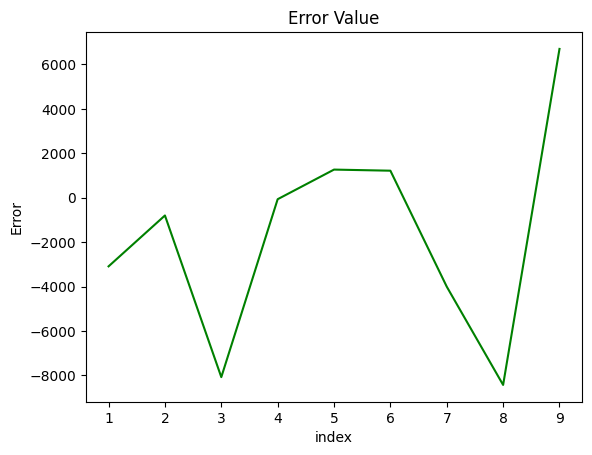

In [ ]:
# plotting the error
c = [i for i in range(1,len(ytest)+1,1)]
plt.plot(c, ytest-y_pred, color='green', linestyle='-')
plt.xlabel('index')
plt.ylabel('Error')
plt.title('Error Value')
plt.show()

In [ ]:
# Importing r2_score and mean_squared_error for the evaluation of the model
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [ ]:
# calculate Mean square error
# calculate Root Mean Square error
MSE = mean_squared_error(ytest, y_pred)
RMSE = np.sqrt(MSE)
print('Mean Squared error = ', MSE)
print('Root mean Squared error = ', RMSE)

Mean Squared error =  23370078.800832972
Root mean Squared error =  4834.260936361728


In [ ]:
# Calculate R square value
score = r2_score(ytest, y_pred)
print("R^2 score:", "{:.0%}".format(score))

R^2 score: 97%


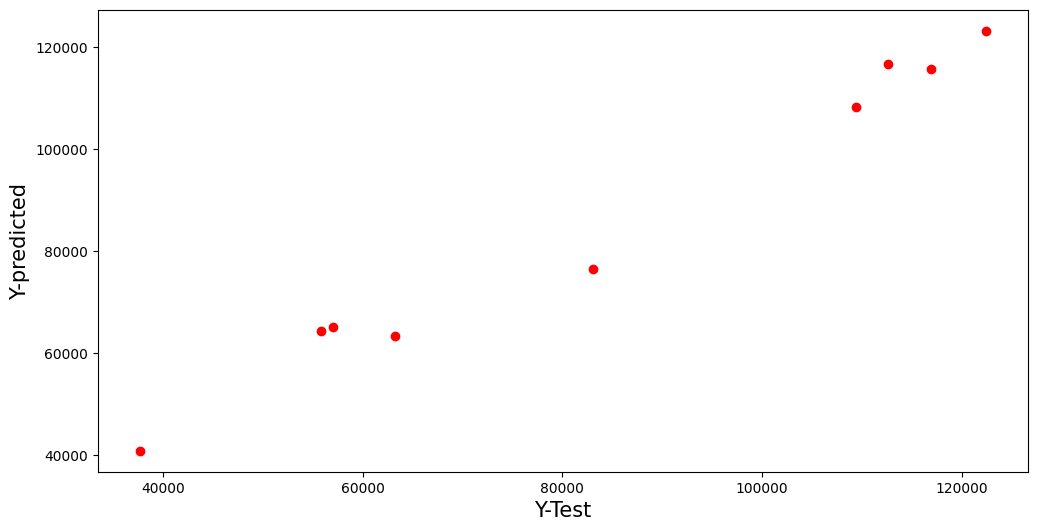

In [ ]:
# Just plot actual and predicted values for more insights
plt.figure(figsize=(12,6))
plt.scatter(ytest,y_pred,color='r',linestyle='-')
plt.ylabel('Y-predicted', fontsize = 15)
plt.xlabel('Y-Test', fontsize = 15)
plt.show()

In [ ]:
print('Intercept of the model:', regressor.intercept_)
print('Coefficient of the line:', regressor.coef_)

Intercept of the model: 26777.391341197625
Coefficient of the line: [9360.26128619]
